In [19]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'

In [21]:
def carregar_dados_csv():
    dados = {}

    arquivos = {
            'orders':'olist_orders_dataset.csv',
            'customers':'olist_customers_dataset.csv',
            'products': 'olist_products_dataset.csv',
            'order_items': 'olist_order_items_dataset.csv',
            'order_payments': 'olist_order_payments_dataset.csv',
            'order_reviews': 'olist_order_reviews_dataset.csv',
            'sellers': 'olist_sellers_dataset.csv'
        }
    
    for nome, arquivo in arquivos.items():
        arquivo_csv = RAW_DIR / arquivo
        if not arquivo_csv.exists():
            raise FileNotFoundError(f"Arquivo {arquivo_csv} não encontrado.")
        
        dados[nome] = pd.read_csv(arquivo_csv)
    
    return dados

In [22]:
dados = carregar_dados_csv()

In [23]:
orders = dados['orders']

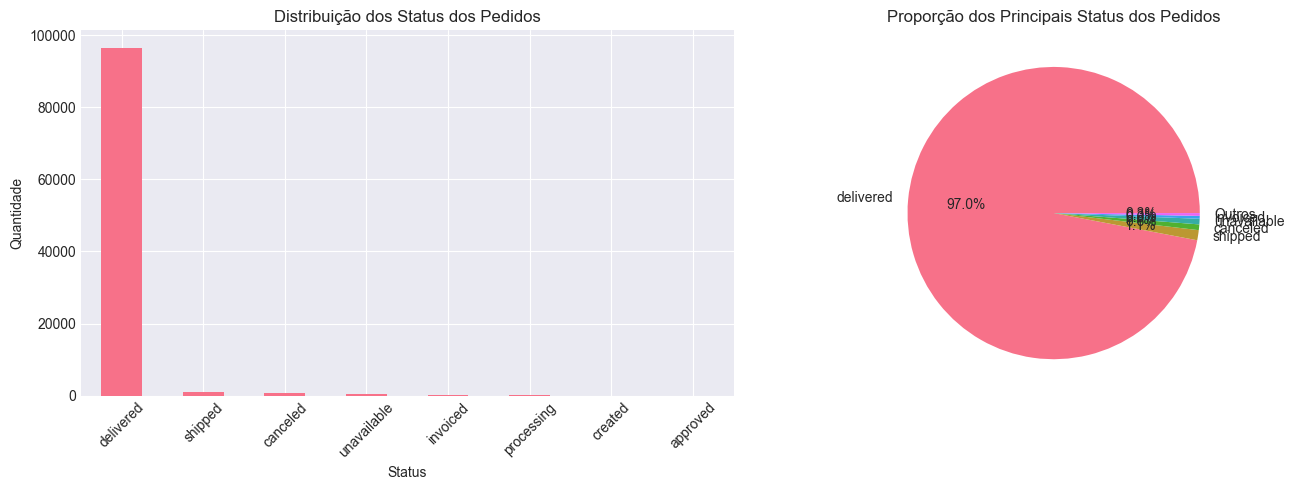

In [ ]:
# Distribuição dos status dos pedidos

status_counts = dados['orders']['order_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribuição dos Status dos Pedidos')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)

principais_status = status_counts.head(5)
outros = status_counts[5:].sum()
if outros > 0:
    principais_status['Outros'] = outros
principais_status.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Proporção dos Principais Status dos Pedidos')

plt.tight_layout()
plt.show()

In [ ]:
# Análise temporal dos pedidos

orders['order_purchase_timestamp'] = pd.to_datetime(dados['orders']['order_purchase_timestamp'])

orders['ano']           = orders['order_purchase_timestamp'].dt.year
orders['mes']           = orders['order_purchase_timestamp'].dt.month
orders['dia']           = orders['order_purchase_timestamp'].dt.day
orders['dia_semana']    = orders['order_purchase_timestamp'].dt.day_name()
orders['hora']          = orders['order_purchase_timestamp'].dt.hour

vendas_mensais = orders.groupby(['ano', 'mes']).size().reset_index(name='quantidade_pedidos')
vendas_mensais['data'] = pd.to_datetime(
    vendas_mensais['ano'].astype(str) + '-' + vendas_mensais['mes'].astype(str) + '-01'
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(vendas_mensais['data'], vendas_mensais['quantidade_pedidos'], marker='o')
axes[0, 0].set_title('Vendas Mensais ao Longo do Tempo')
axes[0, 0].set_xlabel('Data')
axes[0, 0].set_ylabel('Quantidade de Pedidos')

orders['dia_semana'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Distribuição de Pedidos por Dia da Semana')
axes[0, 1].tick_params(axis='x', rotation=45)

orders['hora'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Distribuição de Pedidos por Hora do Dia')
axes[1, 0].set_xlabel('Hora do Dia')
axes[1, 0].set_ylabel('Quantidade de Pedidos')

orders['mes'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição de Pedidos por Mês')
axes[1, 1].set_xlabel('Mês')
axes[1, 1].set_ylabel('Quantidade de Pedidos')

plt.tight_layout()
plt.show()



In [ ]:
# Análise de produtos

products = dados['products']

categorias = products['product_category_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Top 10 categorias de produtos
categorias.head(10).plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 10 Categorias de Produtos')
axes[0].set_xlabel('Quantidade de Produtos')

#Distribuição por peso
products['product_weight_g'].dropna().plot(kind='hist', bins=50, ax=axes[1])
axes[1].set_title('Distribuição do Peso dos Produtos')
axes[1].set_xlabel('Peso (g)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

In [ ]:
# Análise de dimensões

dim_cols = ['product_length_cm', 'product_height_cm', 'product_width_cm']

# Matriz de correlação
corr_matrix = products[dim_cols + ['product_weight_g']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação entre Dimensões e Peso dos Produtos')
plt.show()


In [ ]:
# Análise de clientes

customers = dados['customers']

# Distribuição geográfica dos clientes

cidades = customers['customer_city'].value_counts()
estados = customers['customer_state'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cidades.head(10).plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 10 Cidades com Mais Clientes')
axes[0].set_xlabel('Quantidade de Clientes')

estados.head(10).plot(kind='bar', ax=axes[1])
axes[1].set_title('Top 10 Estados com Mais Clientes')
axes[1].set_xlabel('Quantidade de Clientes')

plt.tight_layout()
plt.show()

In [ ]:
# Análise de vendedores

sellers = dados['sellers']

vendedores_estado = sellers['seller_state'].value_counts()

plt.figure(figsize=(10, 6))
vendedores_estado.plot(kind='bar')
plt.tittle('Distribuição de Vendedores por Estado')
plt.xlabel('Estado')
plt.ylabel('Quantidade de Vendedores')
plt.tick_params(axis='x', rotation=45)
plt.show()

In [ ]:
# Análise de pagamentos

payments = dados['order_payments']

metodos = payments['payment_type'].value_counts()

print("Estatísticas de Valores:")
print(payments['payment_value'].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metodos.plot(kind='pie', ax=axes[0])
axes[0].set_title('Distribuição dos Métodos de Pagamento')

payments['payment_value'].hist(bins=50, ax=axes[1])
axes[1].set_title('Distribuição dos Valores de Pagamento')
axes[1].set_xlabel('Valor do Pagamento')
axes[1].set_ylabel('Frequência')

payments.boxplot(column='payment_value', by='payment_type', ax=axes[2])
axes[2].set_title('Boxplot dos Valores de Pagamento por Tipo')
axes[2].set_xlabel('Tipo de Pagamento')
axes[2].set_ylabel('Valor do Pagamento')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Análise de avaliações

reviews = dados['order_reviews']

notas = reviews['review_score'].value_counts().sort_index()

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])
reviews['tempo_resposta'] = (reviews['review_answer_timestamp'] - reviews['review_creation_date']).dt.days

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Distribuição de notas
notas.plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribuição das Notas de Avaliação')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Quantidade de Avaliações')

#Notas por mês
reviews['mes'] = reviews['review_creation_date'].dt.to_period('M')
media_mensal = reviews.groupby('mes')['review_score'].mean()
media_mensal.plot(kind='line', marker='o', ax=axes[1])
axes[1].set_title('Média Mensal das Notas de Avaliação')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Média da Nota')
axes[1].tick_params(axis='x', rotation=45)

#Tempo de resposta
reviews['tempo_resposta'].hist(bins=30, ax=axes[2])
axes[2].set_title('Distribuição do Tempo de Resposta das Avaliações')
axes[2].set_xlabel('Tempo de Resposta (dias)')
axes[2].set_ylabel('Frequência')

plt.tight_layout()
plt.show()



In [ ]:
# Análise de itens de pedidos

items = dados['order_items']

itens_por_pedido = items.groupby('order_id').size()

print("Estatisticas de Preços e Fretes")
print(f"Preço médio do item: R${items['price'].mean():.2f}")
print(f"Preço máximo do item: R${items['price'].max():.2f}")
print(f"Frete médio do item: R${items['freight_value'].mean():.2f}")
print(f"Frete máximo do item: R${items['freight_value'].max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Itens por pedido
itens_por_pedido.hist(bins=20, ax=axes[0])
axes[0].set_title('Distribuição do Número de Itens por Pedido')
axes[0].set_xlabel('Número de Itens')
axes[0].set_ylabel('Frequência')

#Relação entre preço e frete
axes[1].scatter(items['price'], items['freight_value'], alpha=0.3)
axes[1].set_title('Relação entre Preço e Frete dos Itens')
axes[1].set_xlabel('Preço do Item')
axes[1].set_ylabel('Frete do Item')

plt.tight_layout()
plt.show()